In [260]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline




In [261]:
words = open('names.txt').read().splitlines()


In [262]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(stoi)


In [263]:
block_size = 3


In [264]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [265]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))   
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [266]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd ), generator=g)
W1 = torch.rand((n_embd*block_size, n_hidden), generator=g)*(5/3)/((n_embd*block_size)**0.5)
#b1 = torch.rand(n_hidden, generator=g) * .01
W2 = torch.rand((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.rand(vocab_size, generator=g) * 0
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))
parameters = [C, W1, W2, b2, bngain, bnbias]
sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True

In [ ]:
#forward pass

lri = []
lossi = []
stepi = []
max_steps = 200000
batch_size = 32

for i in range(max_steps):
    #batch construction
    xi = torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb, Yb = Xtr[xi], Ytr[xi]
    #forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    #lienar 
    hpreact = embcat @ W1 
    #batch normalization
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    with torch.no_grad():
        bnmean_running = 0.99*bnmean_running + 0.01*bnmean
        bnstd_running = 0.99*bnstd_running + 0.01*bnstd
    #nonlinearity
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    #update 
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.grad = None
    loss.backward()
    #update values
    for p in parameters:
        p.data += -lr*p.grad
    #stats
    if i % 10000 == 0:                      
        print(f'{i:7d}/{max_steps} {loss.item():.4f}')
    lossi.append(loss.log10().item())
    stepi.append(i)
print(loss.item())


      0/200000 3.2938
  10000/200000 1.9965
  20000/200000 1.7909
  30000/200000 2.7700
  40000/200000 2.0364
  50000/200000 2.1546
  60000/200000 2.0642
  70000/200000 2.1808
  80000/200000 2.1280
  90000/200000 2.0344
 100000/200000 2.3569
 110000/200000 2.1121
 120000/200000 2.5618
 130000/200000 2.0169
 140000/200000 1.8227
 150000/200000 1.8959
 160000/200000 1.9263
 170000/200000 2.0549
 180000/200000 1.7273
 190000/200000 1.7097
1.9307265281677246


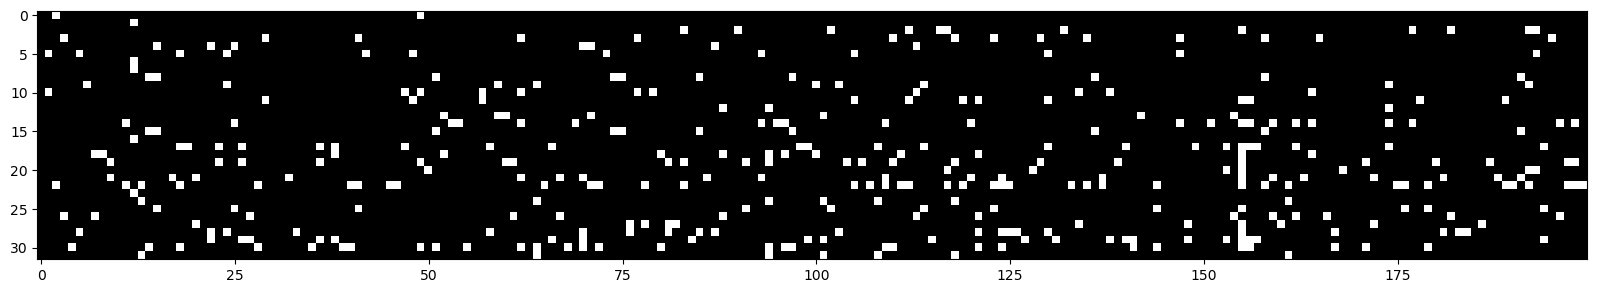

In [268]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > .99, cmap='gray', interpolation='nearest')
plt.show()


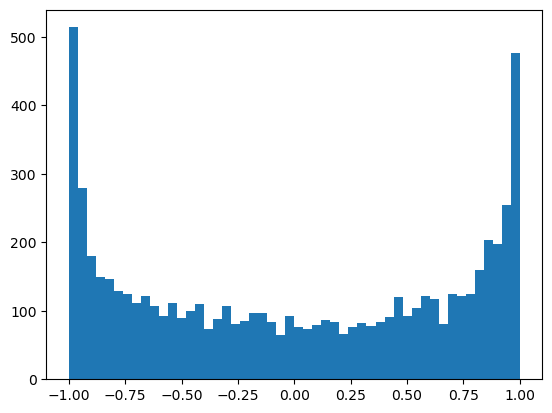

In [269]:
plt.hist(h.view(-1).tolist(), bins=50)
plt.show()

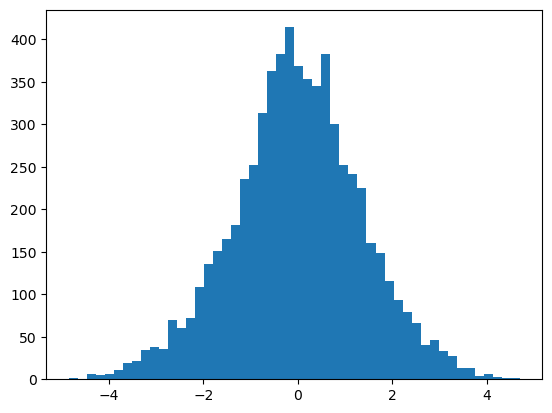

In [270]:
plt.hist(hpreact.view(-1).tolist(), bins=50)
plt.show()

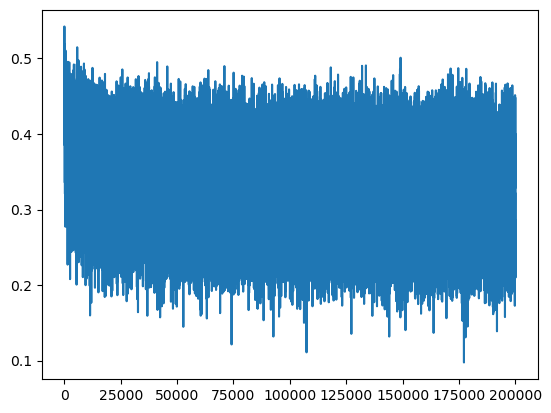

In [271]:
plt.plot(lossi)
plt.show()

In [272]:
@torch.no_grad()
def split_loss(split):
    x, y ={
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item()}')
split_loss('train')
split_loss('val')

train loss: 2.095517158508301
val loss: 2.128246307373047
